# ARG-based analysis of European crows

In [1]:
import tskit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# set up

get population of each sample (defined by Gwee et al)

In [2]:
poplabels = []
with open('data/poplabels.txt','r') as f:
    next(f)
    for line in f:
        poplabels.append(line.strip().split()[1])
pops, ixs = np.unique(poplabels,return_index=True)

aesthetics for plotting

In [3]:
poporder = ['cor1','cor3','cor2',
            'hyb1',
            'cnx5','cnx1','cnx3','cnx2','cnx4','cnx6',
            'hyb2',
            'ori1', 'ori2', 'ori3',
            'pec1']
colormap = {
    'cor1': plt.cm.tab10(3), 'cor2': plt.cm.tab10(3), 'cor3': plt.cm.tab10(3), 
    'hyb1': plt.cm.tab10(4),     
    'cnx1': plt.cm.tab10(0), 'cnx2': plt.cm.tab10(0), 'cnx3': plt.cm.tab10(0), 'cnx4': plt.cm.tab10(0), 'cnx5': plt.cm.tab10(0), 'cnx6': plt.cm.tab10(0),
    'hyb2': plt.cm.tab10(2),  
    'ori1': plt.cm.tab10(1), 'ori2': plt.cm.tab10(1), 'ori3': plt.cm.tab10(1), 
    'pec1': 'black'
}
markermap = {
    'cor1': '<', 'cor2': '>', 'cor3': 'o', 
    'hyb1': 'X',     
    'cnx1': 'o', 'cnx2': 's', 'cnx3': '^', 'cnx4': '>', 'cnx5': '<', 'cnx6': 'v',
    'hyb2': 'X',  
    'ori1': '<', 'ori2': '^', 'ori3': '>', 
    'pec1': 'o'
}
labelmap = {
    'cor1': 'corone-spain', 'cor2': 'corone-germany', 'cor3': 'corone-france', 
    'hyb1': 'corone-cornix hybrid',     
    'cnx1': 'cornix-italy', 'cnx2': 'cornix-bulgaria/levant', 'cnx3': 'cornix-poland/sweden', 'cnx4': 'cornix-russia', 'cnx5': 'cornix-corsica', 'cnx6': 'cornix-iraq',
    'hyb2': 'cornix-orientalis hybrid',  
    'ori1': 'orientalis-west', 'ori2': 'orientalis-north', 'ori3': 'orientalis-east', 
    'pec1': 'pectoralis'
}

chromosome names

In [4]:
chrmap =  {
           'chr1': 'NC_046332.1',
           'chr1A': 'NC_047057.1',
           'chr2': 'NC_046333.1',
           'chr3': 'NC_047056.1',
           'chr4': 'NC_046334.1',
           'chr4A': 'NC_047058.1',
           'chr5': 'NC_046335.1',
           'chr6': 'NC_046336.1',
           'chr7': 'NC_046337.1',
           'chr8': 'NC_046338.1',
           'chr9': 'NC_046339.1',
           'chr10': 'NC_046340.1',
           'chr11': 'NC_046341.1',
           'chr12': 'NC_046342.1',
           'chr13': 'NC_046343.1',
           'chr14': 'NC_046344.1',
           'chr15': 'NC_046345.1',
           'chr17': 'NC_046346.1',
           'chr18': 'NC_046347.1',
           'chr19': 'NC_046348.1',
           'chr20': 'NC_046349.1',
           'chr21': 'NC_046350.1',
           'chr22': 'NC_046351.1',
           'chr23': 'NC_046352.1',
           'chr24': 'NC_046353.1',
           'chr26': 'NC_046354.1',
           'chr27': 'NC_046355.1',
           'chr28': 'NC_046356.1',
           'scaffold1': 'NW_024108678.1', 
           'scaffold2': 'NW_024108687.1',
           'scaffold3': 'NW_024108688.1',
           'scaffold4': 'NW_024108689.1',
           'scaffold5': 'NW_024108690.1',
           'scaffold6': 'NW_024108691.1',
           'scaffold7': 'NW_024108692.1',
           'scaffold8': 'NW_024108693.1',
           'scaffold9': 'NW_024108694.1',
           'scaffold10': 'NW_024108679.1',
           'scaffold11': 'NW_024108680.1',
           'scaffold12': 'NW_024108681.1',
           'scaffold14': 'NW_024108682.1',
           'scaffold15': 'NW_024108683.1',
           'scaffold16': 'NW_024108684.1',
           'scaffold17': 'NW_024108685.1',
           'scaffold18': 'NW_024108686.1',
           'chrZ': 'NC_046357.1',
           'chrM': 'NC_062298.1',
}

sample locations

In [5]:
sample_locations = np.load('data/locations.npy').repeat(2,axis=0)

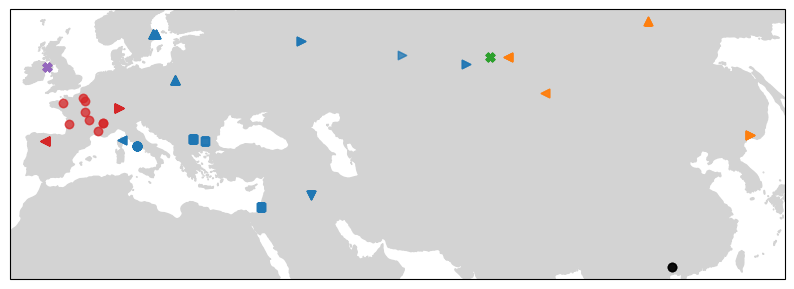

In [6]:
fig = plt.figure(figsize=(10,10))

projection = ccrs.Robinson()
data_crs = ccrs.PlateCarree() #data supplied in lat/long

ax = plt.axes(projection=projection)
ax.add_feature(cfeature.LAND, color='lightgray')

for pop in poporder:
    data = sample_locations[np.where(np.array(poplabels)==pop)]
    ax.scatter(data[:,0], data[:,1], color=colormap[pop], alpha=0.5, marker=markermap[pop], transform=data_crs)

# plt.savefig('plots/sample_locations.png')
plt.show()

# results

## 1. pca for generic chromosome roughly matches geograhy (isolation by distance)

In [7]:
chrname = 'chr1'
# ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])
# pca = ts.pca(2, random_seed=1) #run pca with 2 axes
# np.save('data/pca_%s.npy' %chrname, pca.factors)
pcafactors = np.load('data/pca_%s.npy' %chrname)

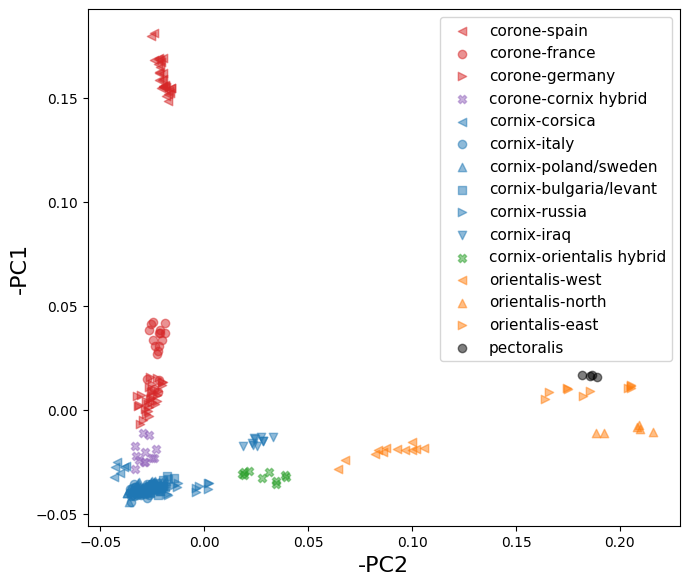

In [10]:
fig = plt.figure(figsize=(7,7))

ax = plt.subplot()

for pop in poporder:
    data = pcafactors[np.where(np.array(poplabels)==pop)]
    ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])

ax.legend(fontsize=11)

ax.set_xlabel('-PC2', fontsize=16)
ax.set_ylabel('-PC1', fontsize=16)
ax.set_aspect(1)

plt.tight_layout()
# plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

## 2. pca for chr18 is different: corone collapse, hybrids spread

In [11]:
chrname = 'chr18'
# ts18 = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])# 
# pca18 = ts18.pca(2, random_seed=1) #run pca with 2 axes
# np.save('data/pca_%s.npy' %chrname, pca18.factors)
pcafactors18 = np.load('data/pca_%s.npy' %chrname)

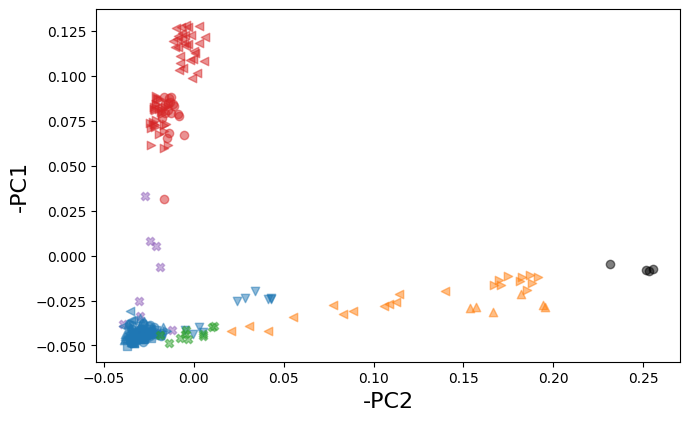

In [12]:
fig = plt.figure(figsize=(7,7))

ax = plt.subplot()

for pop in poporder:
    data = pcafactors18[np.where(np.array(poplabels)==pop)]
    ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])

# ax.legend()

ax.set_xlabel('-PC2', fontsize=16)
ax.set_ylabel('-PC1', fontsize=16)
ax.set_aspect(1)

plt.tight_layout()
plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

## 3. fst (corone-cornix) peak on chr18

In [13]:
fst = []
windows = []
fstchrs = []
for c in chrmap.keys():
    try:
        fst.append(np.load('data/fst_cor-cnx_%s.npy' %chrmap[c]))
        windows.append(np.load('data/fstwindows_cor-cnx_%s.npy' %chrmap[c]))
        fstchrs.append(c)
    except:
        print('missing' + c)

missingscaffold4
missingscaffold5
missingscaffold6
missingscaffold7
missingscaffold8
missingscaffold9
missingscaffold11
missingscaffold12
missingscaffold18
missingchrZ
missingchrM


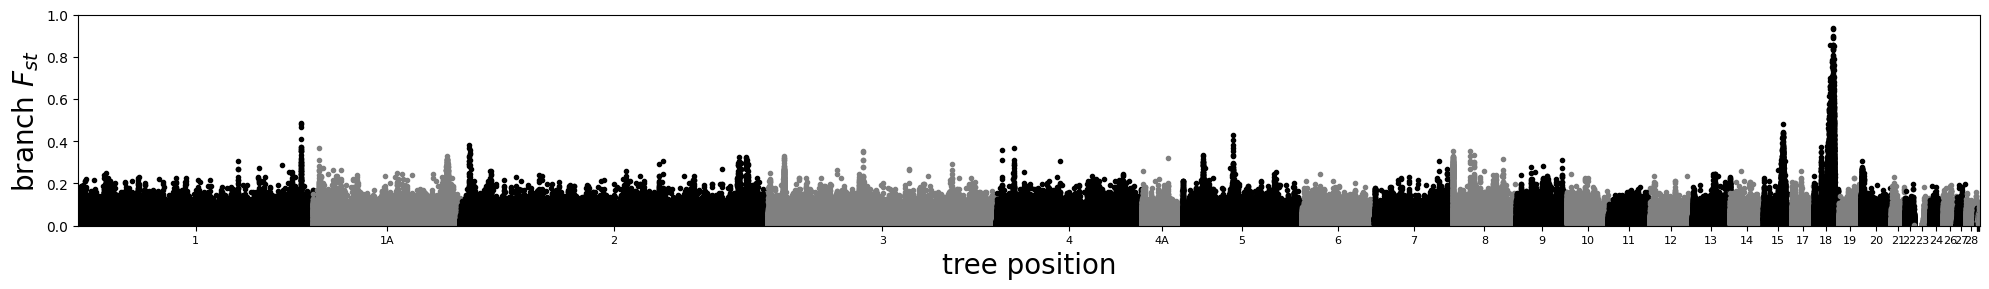

In [16]:
def colors(i):
    if i%2 == 0:
        return 'k'
    else:
        return 'gray'

fig = plt.figure(figsize=(20,3))
ax = plt.axes()

end = 0
xticks = []
for i,[b,f] in enumerate(zip(windows,fst)):
    ax.plot([end+i for i in b[:-1]],f,'.',color=colors(i))
    xticks.append(end + b[-1]/2)
    end += b[-1]
    
# plt.plot([0,end],[0.2,0.2],'--k')
ax.set_xlim(0,end)
ax.set_ylim(0,1)
ax.set_xticks(xticks,[c[3:] if c[:3]=='chr' else '' for c in fstchrs], fontsize=8)
ax.set_ylabel(r'branch $F_{st}$', fontsize=20)
ax.set_xlabel('tree position', fontsize=20)

plt.tight_layout()
# plt.savefig('plots/fst_corone-cornix.png')
plt.show()

## 4. fst peak on chr18 due to gene flow barrier, not sweeps

and we can dig into the cause of this fst peak a bit -- barrier locus vs species-specific sweeps (see wang & coop 2022)

In [17]:
chrname = 'chr18'
ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])
window = list(ts.breakpoints())
windows = [(i+j)/2 for i,j in zip(window[1:],window[:-1])]

In [19]:
# coroneix = [i for i,j in enumerate(poplabels) if j[2]=='r']
# cornixix = [i for i,j in enumerate(poplabels) if j[2]=='x']
# maxtmrcas = []
# mintmrcas = []
# for tree in ts.trees():
#     maxtmrca = [0,0]
#     for n,ixs in enumerate([coroneix,cornixix]):
#         for i in ixs:
#             for j in ixs[:i]:
#                 tmrca = tree.tmrca(i,j)
#                 if tmrca > maxtmrca[n]:
#                     maxtmrca[n] = tmrca
#     maxtmrcas.append(maxtmrca)
#     mintmrca = tree.time(tree.root)
#     for i in coroneix:
#         for j in cornixix:
#             tmrca = tree.tmrca(i,j)
#             if tmrca < mintmrca:
#                 mintmrca = tmrca
#     mintmrcas.append(mintmrca)
# np.save('data/maxtmrcas_chr18.npy', np.array(maxtmrcas))
# np.save('data/mintmrcas_chr18.npy', np.array(mintmrcas))
maxtmrcas = np.load('data/maxtmrcas_chr18.npy')
mintmrcas = np.load('data/mintmrcas_chr18.npy')

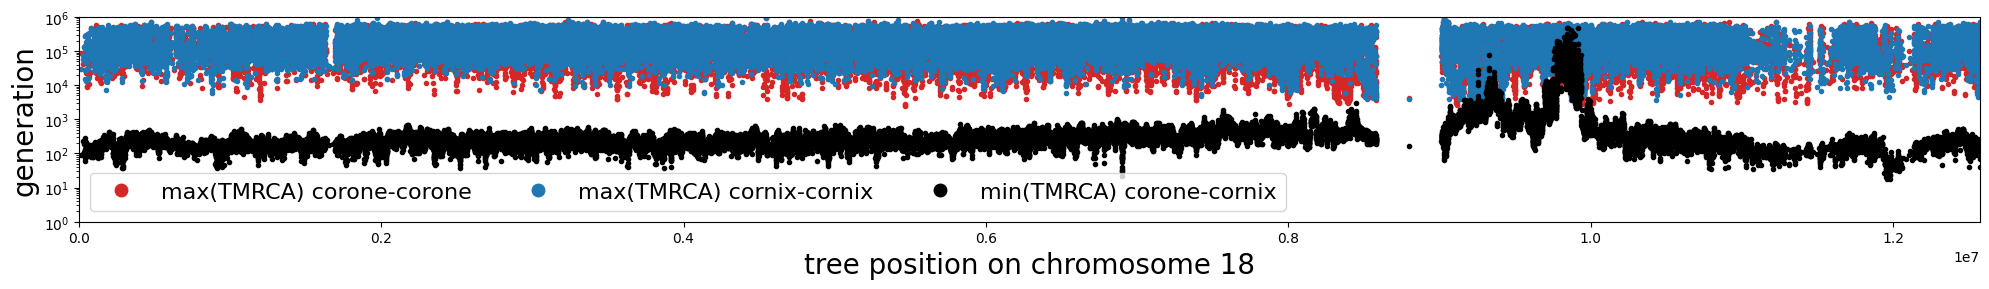

In [26]:
fig = plt.figure(figsize=(20,3))
ax = plt.axes() 


ax.plot(windows, maxtmrcas[:,0], '.', label='max(TMRCA) corone-corone', color=plt.cm.tab10(3))
ax.plot(windows, maxtmrcas[:,1], '.', label='max(TMRCA) cornix-cornix', color=plt.cm.tab10(0))

ax.plot(windows, mintmrcas, '.', label='min(TMRCA) corone-cornix', color='k')

ax.set_xlim(0,windows[-1])
ax.set_yscale('log')
ax.set_ylim(1,1e6)
ax.set_xlabel('tree position on chromosome 18', fontsize=20)
ax.set_ylabel('generation', fontsize=20)
plt.legend(ncols=3, fontsize=16, markerscale=3)
plt.tight_layout()

# plt.savefig('plots/tmrcas_chr18.png')
plt.show()

## 5. Directly visualizing the high fst tree

In [29]:
c = 'chr18'
fst = np.load('data/fst_cor-cnx_%s.npy' %chrmap[c]) #from snakemake
ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[c])

In [30]:
styles = []
for i in ts.samples():
    if poplabels[i][2]=='r':
        color = 'red'
    elif poplabels[i][2]=='x':
        color = 'blue'
    elif poplabels[i][0]=='o':
        color = 'orange'
    elif poplabels[i][0]=='p':
        color = 'black'
    elif poplabels[i][3]=='1':
        color = 'purple'
    elif poplabels[i][3]=='2':
        color = 'green'
    s = f".n{i} .sym " + "{" + f"fill: {color}" + "}"    
    styles.append(s)
css_string = " ".join(styles)

In [31]:
peak = np.nanargmax(fst)
print(peak)
tree = ts.at_index(peak)

33023


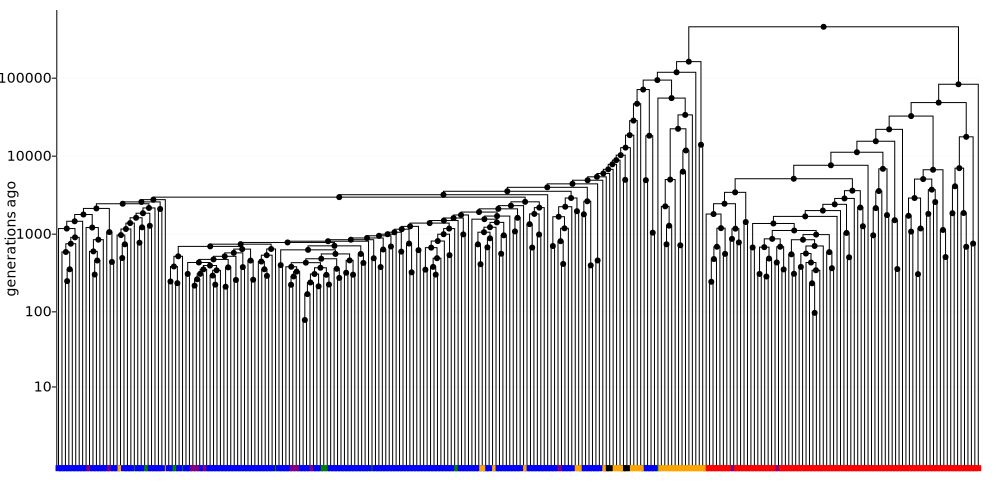

In [37]:
tree.draw_svg(
    size=(1000,500),
    node_labels={}, mutation_labels={}, style=css_string, omit_sites=True,
    time_scale="log_time",  y_axis=True, y_gridlines=True, y_ticks=[10, 100, 1000, 10000,100000], y_label="generations ago",
    # path='plots/fst_tree.svg'
)

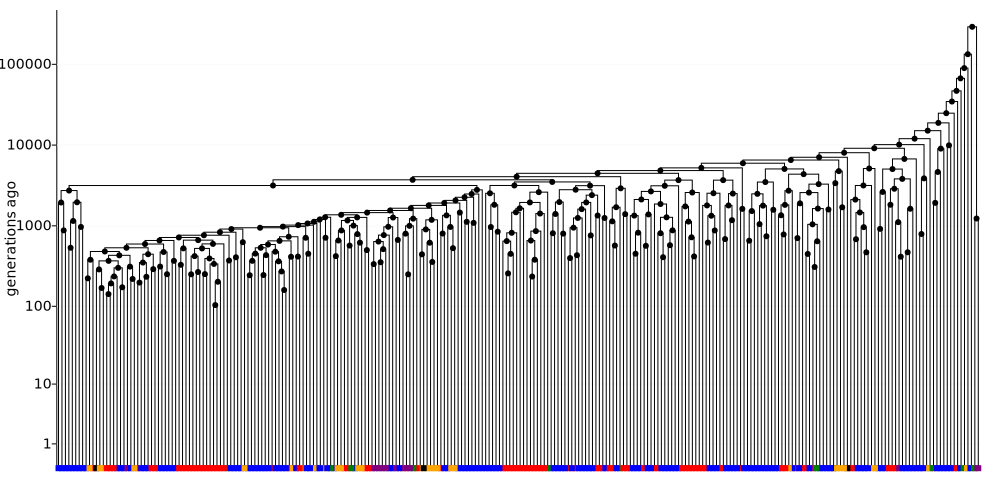

In [38]:
# i = np.random.choice(ts.num_trees)
i = 2453
tree = ts.at_index(i)
tree.draw_svg(
    size=(1000,500),
    node_labels={}, mutation_labels={}, style=css_string, omit_sites=True,
    time_scale="log_time",  y_axis=True, y_gridlines=True, y_ticks=[1, 10, 100, 1000, 10000,100000], y_label="generations ago",
    # path='plots/random_tree.svg'
)

## 6. cornix isnt especially (un)related to orientalis at the inversion

In [49]:
chrname = 'chr18'
ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])
window = list(ts.breakpoints())
windows = [(i+j)/2 for i,j in zip(window[1:],window[:-1])]

In [8]:
# cornixix = [i for i,j in enumerate(poplabels) if j[2]=='x']
# orientalisix = [i for i,j in enumerate(poplabels) if j[0]=='o']
# maxtmrcas = []
# mintmrcas = []
# for tree in ts.trees():
#     maxtmrca = [0,0]
#     for n,ixs in enumerate([orientalisix,cornixix]):
#         for i in ixs:
#             for j in ixs[:i]:
#                 tmrca = tree.tmrca(i,j)
#                 if tmrca > maxtmrca[n]:
#                     maxtmrca[n] = tmrca
#     maxtmrcas.append(maxtmrca)
#     mintmrca = tree.time(tree.root)
#     for i in orientalisix:
#         for j in cornixix:
#             tmrca = tree.tmrca(i,j)
#             if tmrca < mintmrca:
#                 mintmrca = tmrca
#     mintmrcas.append(mintmrca)
# np.save('data/maxtmrcas_chr18_cnx-ori.npy', np.array(maxtmrcas))
# np.save('data/mintmrcas_chr18_cnx-ori.npy', np.array(mintmrcas))
maxtmrcas = np.load('data/maxtmrcas_chr18_cnx-ori.npy')
mintmrcas = np.load('data/mintmrcas_chr18_cnx-ori.npy')

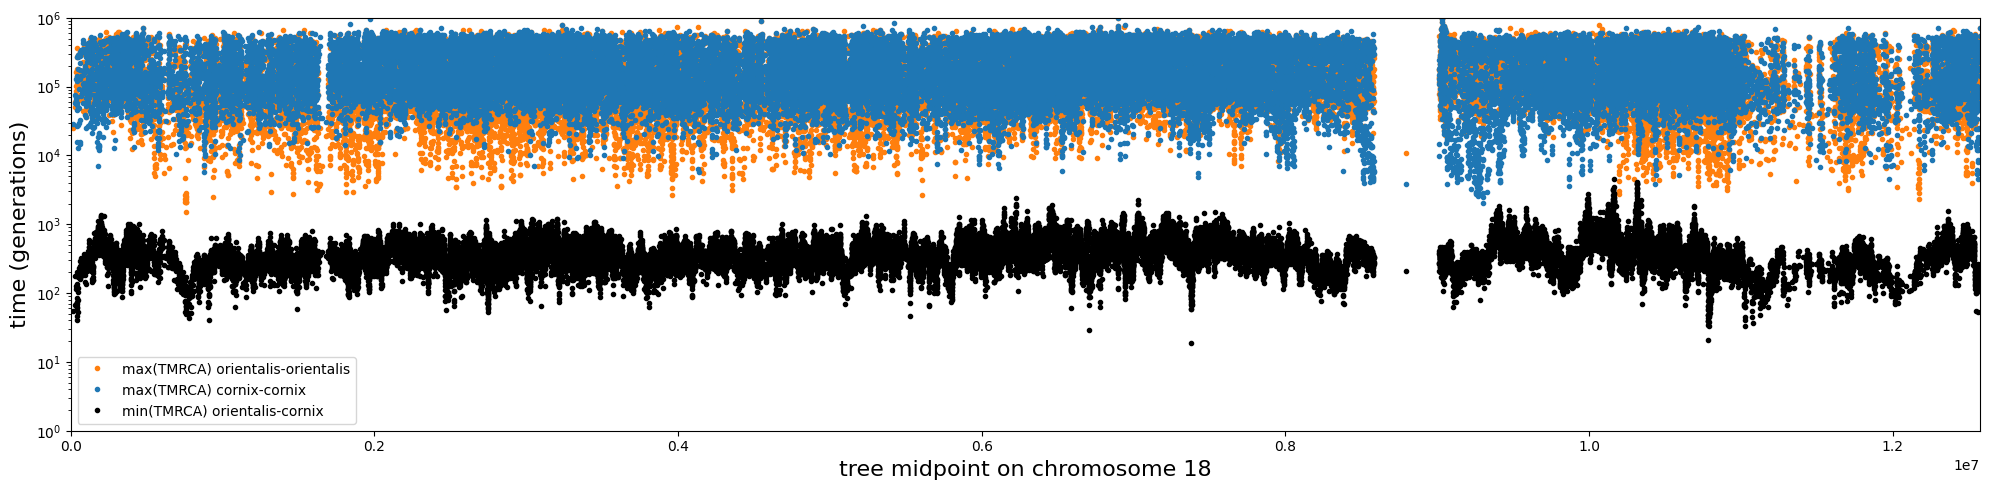

In [9]:
fig = plt.figure(figsize=(20,5))
ax = plt.axes() 


ax.plot(windows, maxtmrcas[:,0], '.', label='max(TMRCA) orientalis-orientalis', color=plt.cm.tab10(1))
ax.plot(windows, maxtmrcas[:,1], '.', label='max(TMRCA) cornix-cornix', color=plt.cm.tab10(0))

ax.plot(windows, mintmrcas, '.', label='min(TMRCA) orientalis-cornix', color='k')

ax.set_xlim(0,windows[-1])
ax.set_yscale('log')
ax.set_ylim(1,1e6)
ax.set_xlabel('tree midpoint on chromosome 18', fontsize=16)
ax.set_ylabel('time (generations)', fontsize=16)
plt.legend()
plt.tight_layout()

# plt.savefig('plots/tmrcas_chr18_cnx-ori.png')
plt.show()

In [10]:
fst = []
windows = []
fstchrs = []
for c in chrmap.keys():
    try:
        fst.append(np.load('data/fst_ori-cnx_%s.npy' %chrmap[c]))
        windows.append(np.load('data/fstwindows_ori-cnx_%s.npy' %chrmap[c]))
        fstchrs.append(c)
    except:
        print('missing' + c)

missingscaffold4
missingscaffold5
missingscaffold6
missingscaffold7
missingscaffold8
missingscaffold9
missingscaffold11
missingscaffold12
missingscaffold18
missingchrZ
missingchrM


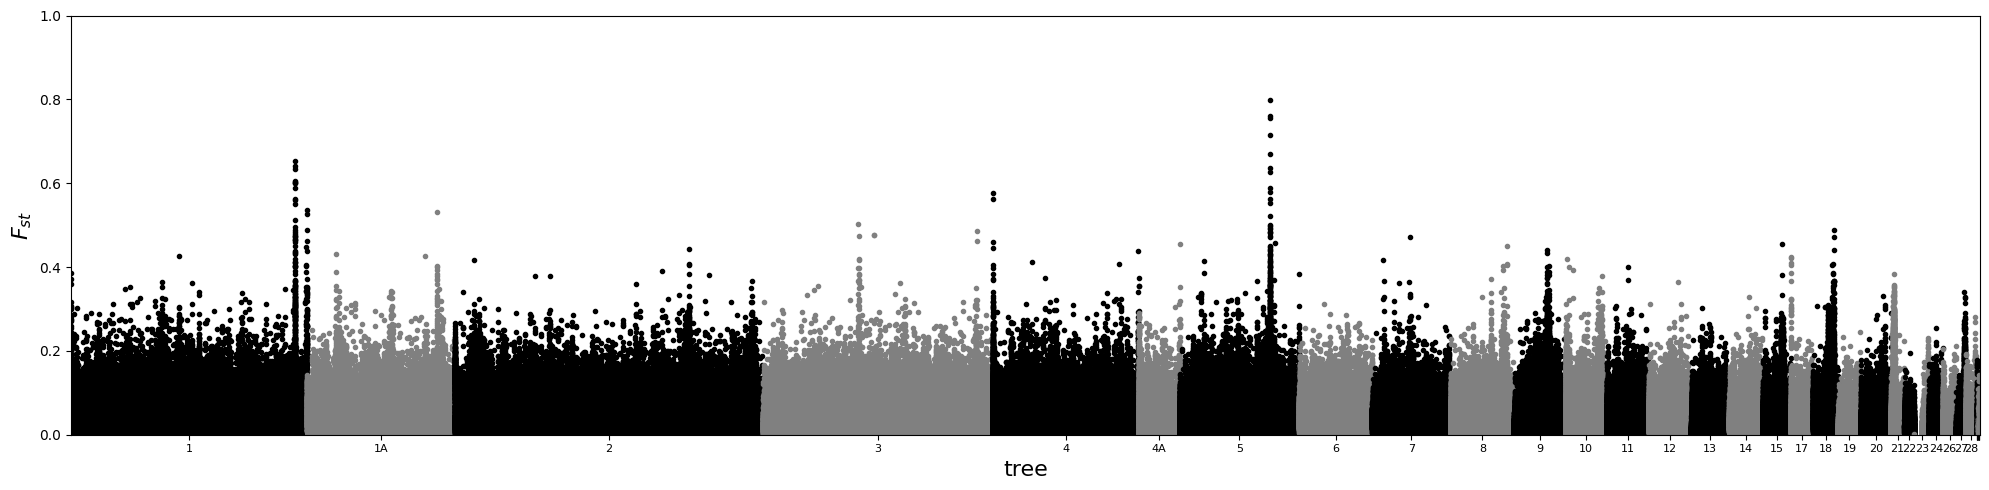

In [11]:
def colors(i):
    if i%2 == 0:
        return 'k'
    else:
        return 'gray'

fig = plt.figure(figsize=(20,5))
ax = plt.axes()

end = 0
xticks = []
for i,[b,f] in enumerate(zip(windows,fst)):
    ax.plot([end+i for i in b[:-1]],f,'.',color=colors(i))
    xticks.append(end + b[-1]/2)
    end += b[-1]
    
# plt.plot([0,end],[0.2,0.2],'--k')
ax.set_xlim(0,end)
ax.set_ylim(0,1)
ax.set_xticks(xticks,[c[3:] if c[:3]=='chr' else '' for c in fstchrs], fontsize=8)
ax.set_ylabel(r'$F_{st}$', fontsize=16)
ax.set_xlabel('tree', fontsize=16)

plt.tight_layout()
plt.savefig('plots/fst_orientalis-cornix.png')
plt.show()

## dolores

make popsize file

In [14]:
coal = []
with open('dolores/crows/134inds.coal') as f:
    next(f)
    for line in f:
        coal.append([float(i) for i in line.split()])

In [15]:
times = coal[0]
nes = [1/i for i in coal[1][2:]]

In [17]:
# with open('dolores/crows/chr18.popsize', 'w') as f:
#     for t,n in zip(times, nes):
#         f.write('%s, %s\n' %(t,n))
# manually changed last ne to NA to be compatible with dolores

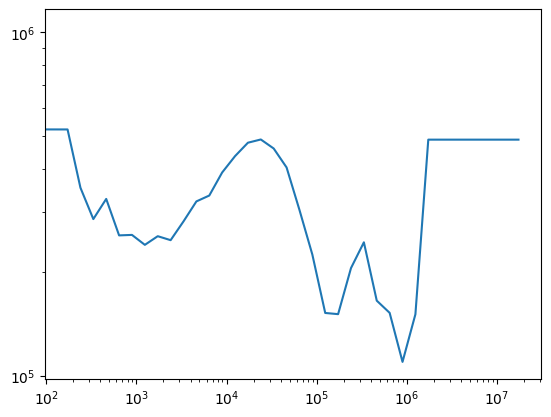

In [18]:
plt.plot(times, nes)
plt.yscale('log')
plt.xscale('log')
plt.show()

check recombination map

In [19]:
rmap = []
with open('dolores/crows/NC_046347.1.map') as f:
    next(f)
    for line in f:
        rmap.append([float(i) for i in line.split()])

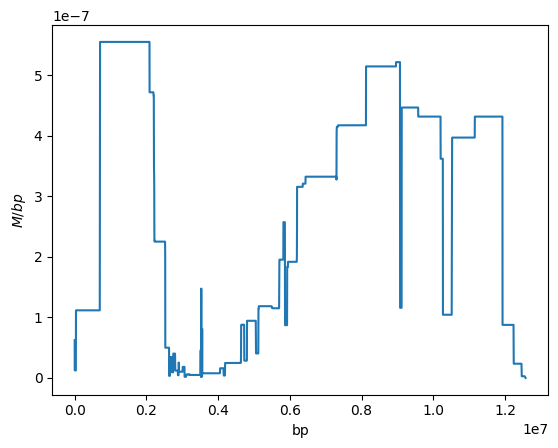

In [20]:
plt.plot([rmap[-1][0]-i[0] for i in rmap], #flipping around to compare to weissenstein fig 5a
         [i[1]*1e6/100 for i in rmap]) #M/bp
plt.xlabel('bp')
plt.ylabel(r'$M/bp$')
plt.show()

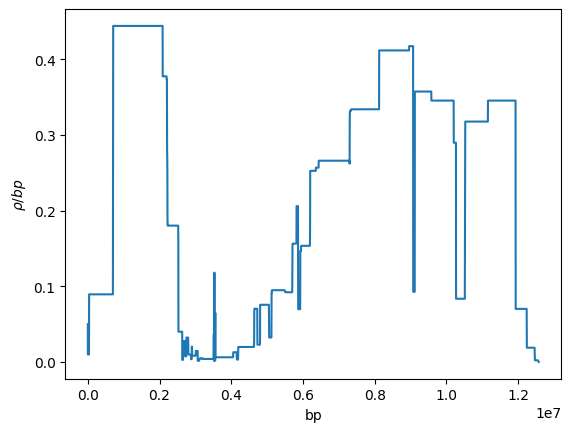

In [21]:
ne=2e5 #value used to convert from LDhelmet to cM/Mb (from most recent 2ne for all samples from relate?)
# ne=6.5e5 #recent ne for eurn1 from gwee fig 2
plt.plot([rmap[-1][0]-i[0] for i in rmap],
         [i[1]*4*ne*1e6/100 for i in rmap]) #convert cM/Mb to rho/bp
plt.xlabel('bp')
plt.ylabel(r'$\rho/bp$')
plt.show()

this is an order too big by typo, divide by 10 (tabris redid tree inference after correcting)

In [22]:
# with open('dolores/crows/chr18.map','w') as f:
#     f.write('Chromosome  Position(bp)  Rate(cM/Mb)  Map(cM)\n')
#     for i in rmap:
#         f.write('chr18  %d  %s  %s\n' %(int(i[0]),i[1]/10,i[2]/10))

dolores output (see startup.sh for how to run)

In [28]:
dol_data = []
with open('dolores/crows/chr18_output/chr18_output.csv','r') as f:
    for i,line in enumerate(f):
        if i==0:
            print(line)
        else:
            dol_data.append(line.split(','))

name,genetic_map,total_clades,clade_num,clade_id,nlog10p_test1,nlog10p_test2,cladesize,span,start,end,mut_span,left_mut,right_mut,num_mutations,merged,chunk_index,tree_index,node_id



In [29]:
chrname = 'chr18'
ts = tskit.load('data/trees/%s/134inds.trees' %chrmap[chrname])
window = list(ts.breakpoints())
windows = [(i+j)/2 for i,j in zip(window[1:],window[:-1])]

there appear to be two clades that last the entire chromosome, but if we ignore them (with ylims) we might be seeing a peak around the inversion for test 2?

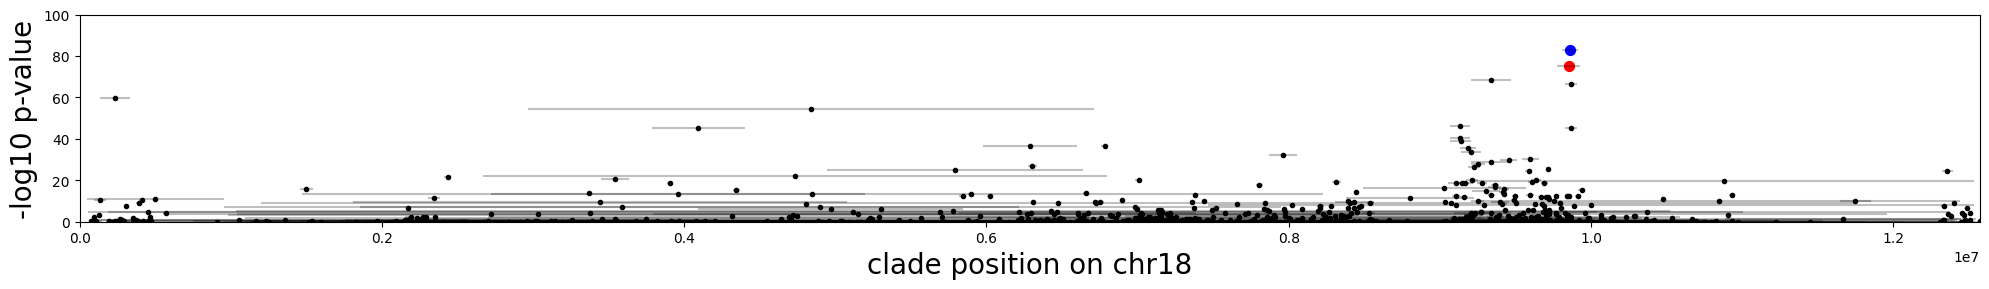

In [32]:
fig = plt.figure(figsize=(20,3))
ax = plt.axes()

pos = [(int(i[10])+int(i[9]))/2 for i in dol_data]
# plt.scatter(pos,[float(i[5]) for i in dol_data], marker='.') #test 1 (nothing significant)
ax.scatter(pos,[float(i[6]) for i in dol_data], marker='.', c='k') #test 2
ax.hlines(xmin=[int(i[9]) for i in dol_data],xmax=[int(i[10]) for i in dol_data],y=[float(i[6]) for i in dol_data], color='k', alpha=0.25)
ax.scatter(pos[633],[float(i[6]) for i in dol_data][633], marker='.', c='r', s=200) #test 2 most likely candidate
ax.scatter(pos[637],[float(i[6]) for i in dol_data][637], marker='.', c='b', s=200) #test 2 most likely candidate

ax.set_xlim(0,windows[-1])
ax.set_ylim(0,100) #comment out to see the two clades we are ignoring
ax.set_ylabel('-log10 p-value', fontsize=20)
ax.set_xlabel('clade position on chr18', fontsize=20)

plt.tight_layout()
# plt.savefig('plots/dolores-chr18.png')
plt.show()

lets take a look at what clades those are

In [29]:
for i,d in enumerate(dol_data):
    if float(d[6])>60:
        print(d)

['chr18', 'HapMapII_GRCh37', '2672380', '1134', '0', '4.695493309039948e-08', '5210.18889621944', '267', '12513322', '45422', '12558744', '12513146', '45525', '12558671', '814', '1316', '0', '15', '264645\n']
['chr18', 'HapMapII_GRCh37', '2672380', '2732', '6', '5.485327718595699e-08', '4986.544348508511', '267', '12444881', '78260', '12523141', '12435773', '84259', '12520032', '766', '1104', '0', '36', '265380\n']
['chr18', 'HapMapII_GRCh37', '2672380', '2033566', '448', '7.443496924722481e-11', '114.13299584411371', '264', '302788', '8263736', '8566524', '300490', '8265713', '8566203', '26', '39', '29', '617', '265487\n']
['chr18', 'HapMapII_GRCh37', '2672380', '2074033', '507', '2.9644794323931097e-11', '149.56016224229953', '264', '418649', '9076552', '9495201', '418606', '9076594', '9495200', '33', '32', '30', '569', '265494\n']
['chr18', 'HapMapII_GRCh37', '2672380', '2082106', '531', '1.6942139940364213e-11', '68.51283817663091', '254', '260609', '9208318', '9468927', '260381', 

clades 633 and 637 are the candidates, which would correspond to corone (with 78 samples) and the remainder (190 samples)

this is first tree with clade 633 in it, with mrca marked in red

In [43]:
ts = tskit.load('dolores/crows/chr18_output/chr18_chunk32.trees')
tree = ts.at_index(508)

In [44]:
styles = []
for i in ts.samples():
    if poplabels[i][2]=='r':
        color = 'red'
    elif poplabels[i][2]=='x':
        color = 'blue'
    elif poplabels[i][0]=='o':
        color = 'orange'
    elif poplabels[i][0]=='p':
        color = 'black'
    elif poplabels[i][3]=='1':
        color = 'purple'
    elif poplabels[i][3]=='2':
        color = 'green'
    s = f".n{i} > .sym " + "{" + f"fill: {color}" + "}"    
    styles.append(s)
i = 263673
color = 'red'
styles.append(f".n{i} > .sym " + "{" + f"fill: {color}" + "}")
css_string = " ".join(styles)

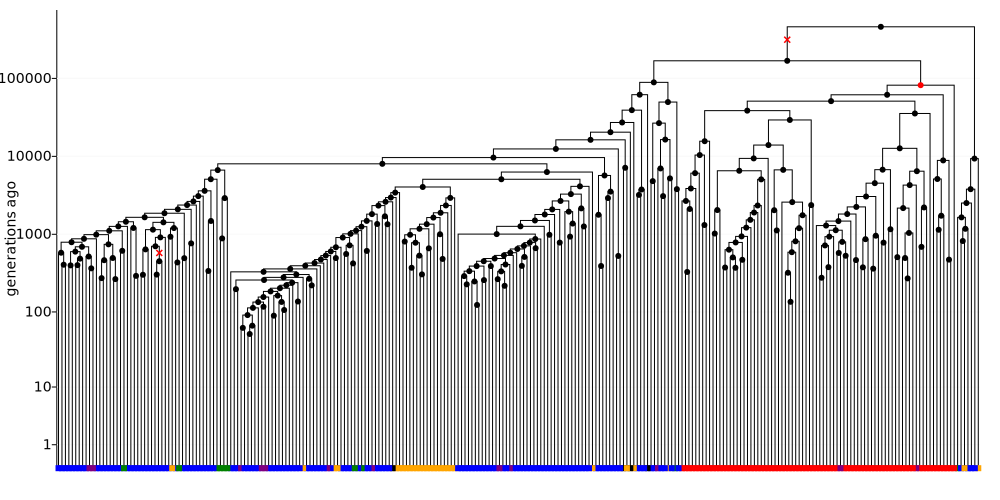

In [45]:
tree.draw_svg(
    size=(1000,500),
    node_labels={}, mutation_labels={}, style=css_string,
    time_scale="log_time",  y_axis=True, y_gridlines=True, y_ticks=[1, 10, 100, 1000, 10000,100000], y_label="generations ago",
    # path='plots/fst_tree.svg'
)

and for clade 637

In [46]:
ts = tskit.load('dolores/crows/chr18_output/chr18_chunk32.trees')
tree = ts.at_index(590)

In [47]:
styles = []
for i in ts.samples():
    if poplabels[i][2]=='r':
        color = 'red'
    elif poplabels[i][2]=='x':
        color = 'blue'
    elif poplabels[i][0]=='o':
        color = 'orange'
    elif poplabels[i][0]=='p':
        color = 'black'
    elif poplabels[i][3]=='1':
        color = 'purple'
    elif poplabels[i][3]=='2':
        color = 'green'
    s = f".n{i} > .sym " + "{" + f"fill: {color}" + "}"    
    styles.append(s)
i = 264467
color = 'blue'
styles.append(f".n{i} > .sym " + "{" + f"fill: {color}" + "}")
css_string = " ".join(styles)

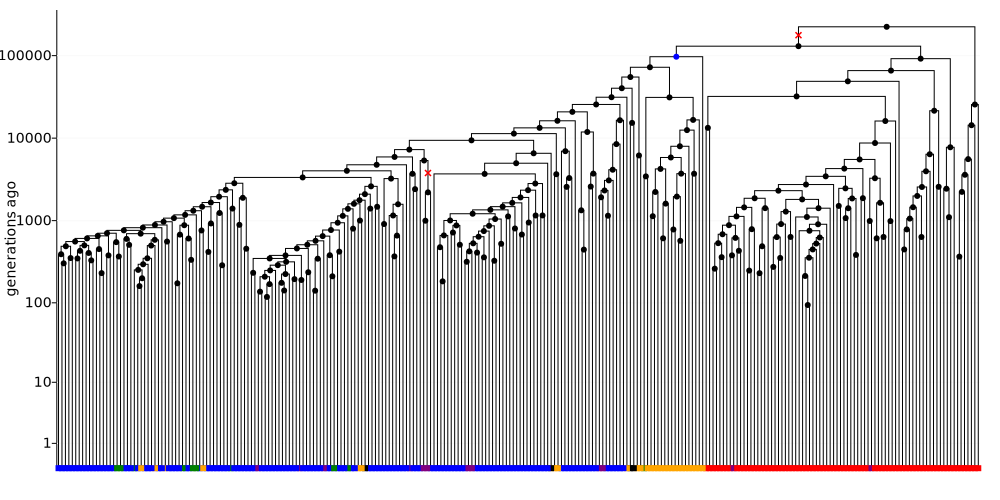

In [48]:
tree.draw_svg(
    size=(1000,500),
    node_labels={}, mutation_labels={}, style=css_string,
    time_scale="log_time",  y_axis=True, y_gridlines=True, y_ticks=[1, 10, 100, 1000, 10000,100000], y_label="generations ago",
    # path='plots/fst_tree.svg'
)

the overlap in span between clades 633 and 637 is positions 9806260 - 9912051, which contains the high fst tree (it is the last tree in clade 637)

In [50]:
ts.at_index(33023)

best to run it on just the french-german-polish-swedish samples to avoid dealing with too much other population structure?